In [34]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [35]:
game_folder = "data/game_data.csv"
time_folder = "data/time_data.csv"
tagged_folder = "data/game_data_with_tags.csv"

game_data = pd.read_csv(game_folder)
time_data = pd.read_csv(time_folder)
tagged_data = pd.read_csv(tagged_folder)

In [36]:
time_data["playtime"] = (time_data["playtime"]/60).astype(int)

In [38]:
tagged_data.sample(10)

,game_id,game_steam_id,game_name,tag_0,tag_1,tag_2,tag_3,tag_4,rating
8811,10528,210550,Angry Birds Space,Casual,Physics,Puzzle,Touch-Friendly,Family Friendly,89.0
1172,1240,225420,Cities in Motion 2,Simulation,Strategy,Transportation,Management,City Builder,60.0
4983,5302,418530,Spelunky 2,Platformer,2D Platformer,Difficult,Perma Death,Online Co-Op,93.0
11253,16527,223410,Perpetuum,Massively Multiplayer,RPG,Mechs,Sandbox,Indie,72.0
12023,18529,2545,RIP 2: Strike Back,Indie,Casual,Arcade,Shooter,Action,65.0
5848,6649,615400,Make It Rain: Love of Money,Free to Play,Casual,Simulation,Strategy,Action,48.0
13117,22647,1428100,Instruments of Destruction,Destruction,Physics,Action,Simulation,3D,92.0
13089,22500,228020,Spacebase DF-9 Prototype,NaN,NaN,NaN,NaN,NaN,NaN
5771,6556,437420,The Secret Order 3: Ancient Times,Casual,Adventure,Hidden Object,Puzzle,Point & Click,86.0
13192,23174,458960,Winning Putt: Golf Online,Free to Play,Sports,Golf,Simulation,Massively Multiplayer,60.0


In [39]:
time_data.sample(10)

,user_id,game_id,playtime
1618680,6104,13806,2
1023163,2334,4805,21
1480976,5345,3933,70
1198210,3392,4359,483
153891,286,10618,1
792785,1179,3721,57
34419,62,3865,5
288696,393,95,2
1303475,4163,11876,4
444414,603,7792,6


In [40]:
game_data.sample(10)

,game_id,game_steam_id,game_name
22444,22445,1093290,The Wild at Heart
28184,28185,38810,Crimecraft: Standard Edition
10821,10822,587970,Dead Drop
26732,26733,1055690,Awakening: The Dreamless Castle
6533,6534,392450,Silver Creek Falls - Chapter 1
6786,6787,761480,Snail Trek - Chapter 3: Lettuce Be
18992,18993,402880,Age of Barbarian Extended Cut
8557,8558,307190,Nicole
31743,31744,653550,Spin the Beat
28251,28252,403490,unknown game


In [41]:
named_time_data = time_data.merge(game_data, on="game_id", how="left")
named_time_data.drop(columns=["game_id"], inplace=True)
# rearange columns
named_time_data = named_time_data[
    [
        "user_id",
        "game_name",
        "playtime",
        "game_steam_id"
    ]
]

In [42]:
named_time_data

,user_id,game_name,playtime,game_steam_id
0,1,Garry's Mod,1346,4000
1,1,Portal,10,400
2,1,The Witcher: Enhanced Edition,8,20900
3,1,World of Goo,10,22000
4,1,Mirror's Edge,6,17410
...,...,...,...,...
1709788,6580,Totally Accurate Battlegrounds,0,823130
1709789,6580,Starfield,2,1716740
1709790,6580,Deadlock,251,1422450
1709791,6580,Team Fortress 2,46,440


In [43]:
# groupyby game_name, sum playtime, count user_id
game_time = named_time_data.groupby("game_steam_id").agg(
    {"playtime": "sum", "user_id": "count", "game_name": "first"}
)
game_time["average_playtime"] = (game_time["playtime"] / game_time["user_id"]).round(2)
# rename columns
game_time.columns = ["total_time", "total_users", "game_name", "avg_time"]
game_time = game_time [
    [
        "total_time",
        "total_users",
        "avg_time",
        "game_name"
    ]
]
game_time.sort_values("total_users", ascending=False, inplace=True)
# get rid of games with game_name unknown game
game_time = game_time[game_time["game_name"] != "unknown game"]
game_time.reset_index(inplace=True)

# get rid of all games with less than 50 users
game_time = game_time[game_time["total_users"] >= 50]
game_time.head(30)

,game_steam_id,total_time,total_users,avg_time,game_name
0,730,7981049,5895,1353.87,Counter-Strike 2
1,10,2355653,4587,513.55,Counter-Strike
2,440,1387201,4368,317.58,Team Fortress 2
3,240,1022714,4109,248.90,Counter-Strike: Source
4,550,416193,4060,102.51,Left 4 Dead 2
5,570,3166377,3738,847.08,Dota 2
6,578080,1502324,3558,422.24,PUBG: BATTLEGROUNDS
7,620,80202,3134,25.59,Portal 2
8,218620,505866,2917,173.42,PAYDAY 2
9,220,64659,2799,23.10,Half-Life 2


In [44]:
data = {
    'game': [],
    'total_time': [],
    'avg_time': [],
    'total_users': []
}
for row in game_time.head(20).iterrows():
    data["game"].append(row[1]["game_name"])
    data["total_time"].append(row[1]["total_time"])
    data["avg_time"].append(row[1]["avg_time"])
    data["total_users"].append(row[1]["total_users"])

In [45]:
data.keys()

dict_keys(['game', 'total_time', 'avg_time', 'total_users'])

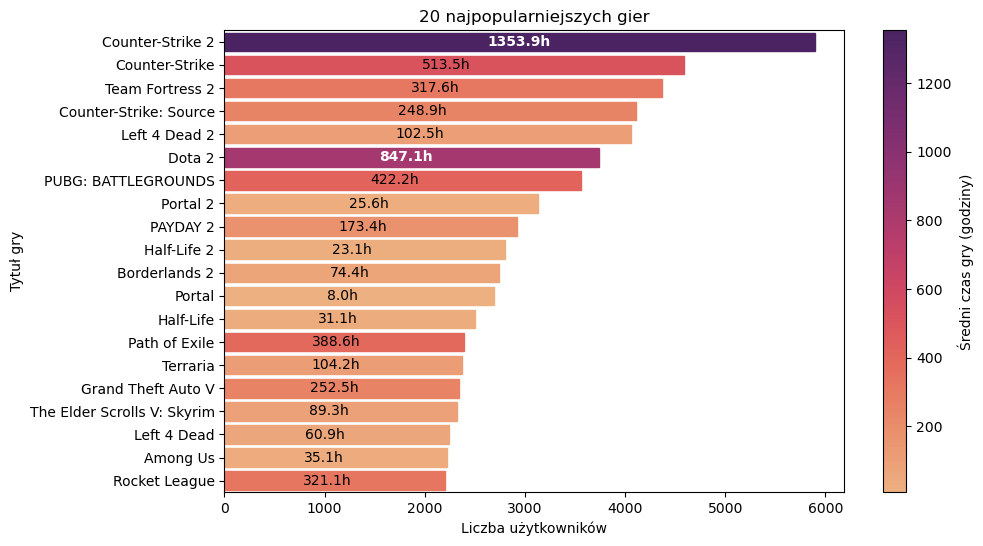

In [46]:
df = pd.DataFrame(data)

# create bar plot with seaborn
fig, ax = plt.subplots(figsize=(10, 6))
bars = sns.barplot(x="total_users", y="game", data=df, ax=ax, orient='h')

# Normalize the values of avg_time for the color gradient
norm = plt.Normalize(df["avg_time"].min(), df["avg_time"].max())

# Create a Seaborn color palette
palette = sns.color_palette("flare", as_cmap=True)

# Map the colors from the Seaborn palette to the bars
colors = palette(norm(df["avg_time"]))

# set the color of each bar
for i, bar in enumerate(bars.patches):
    bar.set_color(colors[i])
    # if i == 0 or 5, set text color to white and font weight to bold
    if i == 0 or i == 5:
        ax.text(bar.get_width() // 2 - 320, bar.get_y() + bar.get_height() / 2, f'{data["avg_time"][i]:.1f}h', va='center', color='white', fontweight='bold')
    else:
        ax.text(bar.get_width() // 2 - 320, bar.get_y() + bar.get_height() / 2, f'{data["avg_time"][i]:.1f}h', va='center')

# Add a color bar (legend) for the avg_time
sm = plt.cm.ScalarMappable(cmap='flare', norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Średni czas gry (godziny)')

ax.set_xlabel("Liczba użytkowników")
ax.set_ylabel("Tytuł gry")
ax.set_title("20 najpopularniejszych gier")

plt.savefig("top20games.png", bbox_inches='tight')

plt.show()

In [56]:
# sort game_time by avg_time
game_time.sort_values("avg_time", ascending=False, inplace=True)
# get rid of games with less than 50 users
game_time = game_time[game_time["total_users"] >= 50]
game_time.head(20)

,game_steam_id,total_time,total_users,avg_time,game_name
0,730,7981049,5895,1353.87,Counter-Strike 2
873,627690,423323,330,1282.80,Idle Champions of the Forgotten Realms
5966,466170,73978,64,1155.91,Idling to Rule the Gods
2511,1147690,156156,153,1020.63,NGU IDLE
3818,400040,90350,105,860.48,ShareX
5,570,3166377,3738,847.08,Dota 2
6139,1013320,51545,62,831.37,Firestone: Online Idle RPG
4396,1891700,74922,91,823.32,Tap Ninja
688,39210,272420,399,682.76,FINAL FANTASY XIV Online
1211,1454400,175225,258,679.17,Cookie Clicker


In [57]:
data = {
    'game': [],
    'total_time': [],
    'avg_time': [],
    'total_users': []
}
for row in game_time.head(20).iterrows():
    data["game"].append(row[1]["game_name"])
    data["total_time"].append(row[1]["total_time"])
    data["avg_time"].append(row[1]["avg_time"])
    data["total_users"].append(row[1]["total_users"])

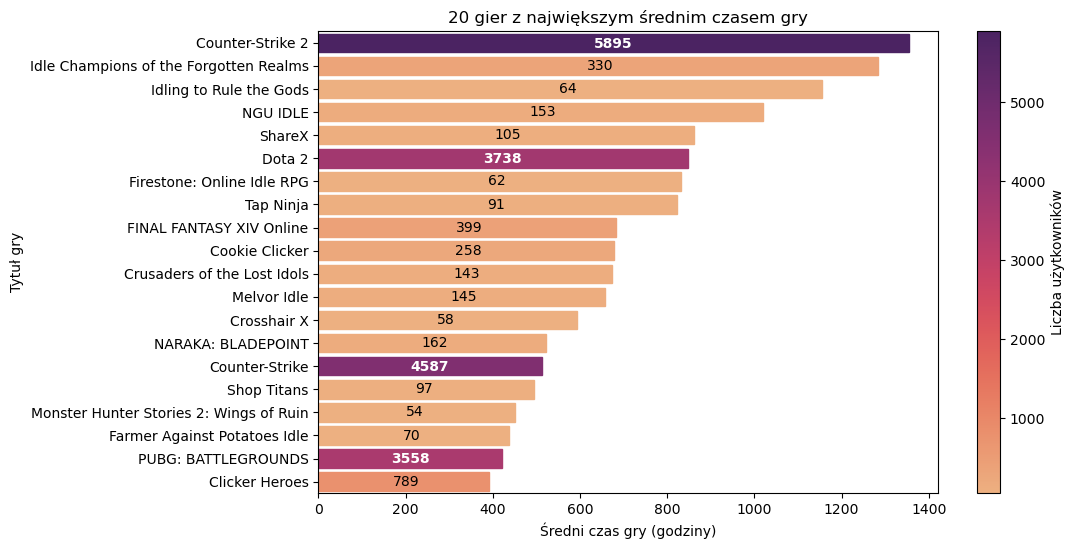

In [58]:
df = pd.DataFrame(data)

# create bar plot with seaborn
fig, ax = plt.subplots(figsize=(10, 6))
bars = sns.barplot(x="avg_time", y="game", data=df, ax=ax, orient='h')

# Normalize the values of avg_time for the color gradient
norm = plt.Normalize(df["total_users"].min(), df["total_users"].max())

# Create a Seaborn color palette
palette = sns.color_palette("flare", as_cmap=True)

# Map the colors from the Seaborn palette to the bars
colors = palette(norm(df["total_users"]))

# set the color of each bar
for i, bar in enumerate(bars.patches):
    bar.set_color(colors[i])
    if i == 0 or i == 14 or i == 5 or i == 18:
        ax.text(bar.get_width() // 2 - 45, bar.get_y() + bar.get_height() / 2 + 0.03, f'{data["total_users"][i]}', va='center', color='white', fontweight='bold')
    else:
        ax.text(bar.get_width() // 2 - 25, bar.get_y() + bar.get_height() / 2, f'{data["total_users"][i]}', va='center')

# Add a color bar (legend) for the avg_time
sm = plt.cm.ScalarMappable(cmap='flare', norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Liczba użytkowników')

ax.set_xlabel("Średni czas gry (godziny)")
ax.set_ylabel("Tytuł gry")
ax.set_title("20 gier z największym średnim czasem gry")

plt.savefig("top20avg.png", bbox_inches='tight')

plt.show()

In [64]:
game_tags = "datanew/game_data_with_tags.csv"

game_tags_data = pd.read_csv(game_tags)
game_tags_data.head()

,game_id,game_steam_id,game_name,tag_0,tag_1,tag_2,tag_3,tag_4,rating
0,1,4000,Garry's Mod,Sandbox,Moddable,Multiplayer,Physics,Building,96.0
1,2,400,Portal,Puzzle,Puzzle Platformer,First-Person,3D Platformer,Singleplayer,98.0
2,3,20900,The Witcher: Enhanced Edition,RPG,Fantasy,Story Rich,Mature,Singleplayer,89.0
3,4,22000,World of Goo,Puzzle,Indie,Physics,Singleplayer,Great Soundtrack,94.0
4,5,17410,Mirror's Edge,Action-Adventure,Parkour,First-Person,Exploration,3D Platformer,87.0


In [65]:
data = {
    "game": [],
    "rating": [],
    "tags": {}
}

for game in game_tags_data.iterrows():
    # check if rating is nan
    if not np.isnan(game[1].rating):
        data["game"].append(game[1].game_name)
        data["rating"].append(int(game[1].rating))
    for i in range(1, 5):
        tag = game[1][f"tag_{i}"]
        # check if tag is nan
        if pd.isnull(tag):
            break
        if tag not in data["tags"]:
            data["tags"][tag] = 1
        else:
            data["tags"][tag] += 1

data

{'game': ["Garry's Mod",
  'Portal',
  'The Witcher: Enhanced Edition',
  'World of Goo',
  "Mirror's Edge",
  'Machinarium',
  'AI War: Fleet Command',
  'Left 4 Dead 2',
  'Beat Hazard',
  'VVVVVV',
  'Gothic 1 Classic',
  'SpaceChem',
  'Portal 2',
  'Terraria',
  'Syberia',
  'Warhammer 40,000: Space Marine - Anniversary Edition',
  'Defy Gravity',
  'LIMBO',
  'PAYDAY: The Heist',
  'Cave Story+',
  'Flatout 3',
  'The Witcher 2: Assassins of Kings Enhanced Edition',
  'Warlock - Master of the Arcane',
  '3SwitcheD',
  'The Binding of Isaac',
  'Worms Armageddon',
  'Planets Under Attack',
  'The Basement Collection',
  'Lucius',
  'Hotline Miami',
  'Scribblenauts Unlimited',
  'Two Worlds: Epic Edition',
  'Iron Sky Invasion',
  'Saints Row: The Third',
  'Thomas Was Alone',
  'Little Inferno',
  'Super Hexagon',
  'Sang-Froid - Tales of Werewolves',
  'Neverwinter',
  'Warframe',
  'Gear Up',
  '8BitMMO',
  'The Plan',
  'Fistful of Frags',
  'You Have to Win the Game',
  'Free

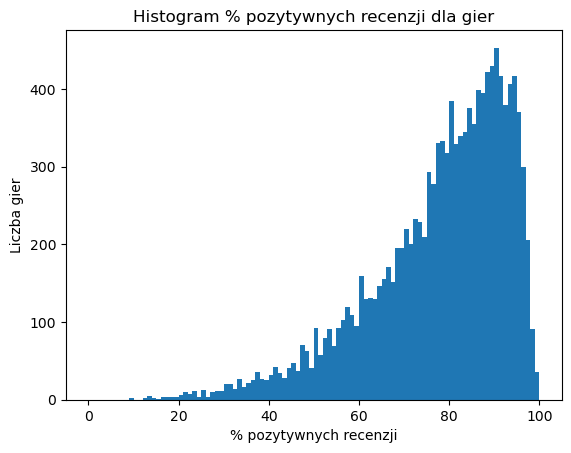

In [66]:
# make a histogram of rating % for games
plt.hist(data["rating"], bins=np.arange(0, 101, 1))
plt.xlabel("% pozytywnych recenzji")
plt.ylabel("Liczba gier")
plt.title("Histogram % pozytywnych recenzji dla gier")

plt.savefig("rating_hist.png", bbox_inches='tight')

plt.show()

In [67]:
# take 20 most popular tags
tags = sorted(data["tags"].items(), key=lambda x: x[1], reverse=True)
tags = tags[:20]
new_tags = []
for i in range(len(tags)-1, -1, -1):
    new_tags.append(tags[i])
new_tags

[('Open World', 477),
 ('Story Rich', 505),
 ('Female Protagonist', 534),
 ('Anime', 535),
 ('Shooter', 539),
 ('FPS', 544),
 ('Point & Click', 551),
 ('2D', 565),
 ('Pixel Graphics', 660),
 ('Platformer', 763),
 ('Singleplayer', 1098),
 ('RPG', 1145),
 ('Puzzle', 1192),
 ('Simulation', 1259),
 ('Strategy', 1294),
 ('Multiplayer', 1324),
 ('Casual', 2074),
 ('Adventure', 2431),
 ('Action', 2777),
 ('Indie', 4171)]

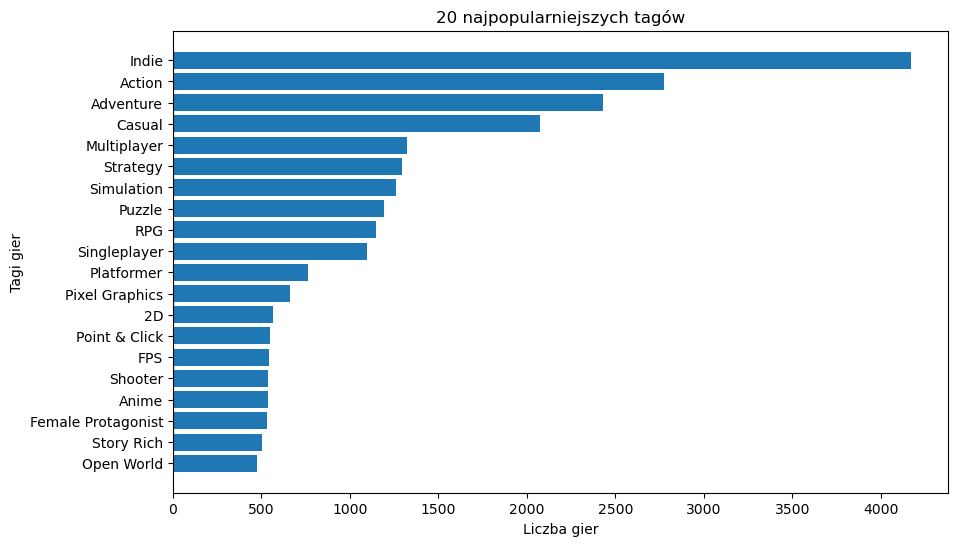

In [68]:
# make a bar plot of the 20 most popular tags
# tags on the y axis, values on the x
plt.figure(figsize=(10, 6))

plt.barh([tag[0] for tag in new_tags], [tag[1] for tag in new_tags])
plt.xlabel("Liczba gier")
plt.ylabel("Tagi gier")
plt.title("20 najpopularniejszych tagów")
# rozkład tagów wśród gier

plt.savefig("tags_bar.png", bbox_inches='tight')

plt.show()
